# Backtest: does the value-growth model actually work, and how consistently?

Notebook 02 evaluates models on a held-out slice drawn from the *same* period as training. That's fine for comparing models against each other, but it isn't the question a fan or a scout would ask: **if we had used this model a year ago, would it have been right?**

The first version of this notebook answered that for one rollback date (June 2025). One walk-forward split is weak evidence: a single good or bad year can flatter or damn a model. This version repeats the exercise at **every six months across the dataset's history**, using the harness in `src/modeling.py`:

- `strict_training_panel` keeps only rows whose outcome had *fully resolved* by the cutoff, including the matching tolerance window around the target date, so nothing dated after the cutoff can leak into training.
- `default_backtest_cutoffs` picks month-start cutoffs every six months, from the first date with enough trailing-form training data to the last date whose outcomes are all known.
- `walk_forward_backtest` trains each model at each cutoff, predicts for every player's latest snapshot as of that date, and scores against what really happened.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from src.panel import HORIZONS_MONTHS, build_snapshot_panel
from src.modeling import (
    TARGET_CLIP,
    default_backtest_cutoffs,
    summarize_backtest,
    walk_forward_backtest,
    walk_forward_interval_backtest,
)

sns.set_theme(style="whitegrid", context="talk")
USD_PER_EUR = 1.08

# One fixed colour per model, in a fixed order, so a model keeps its colour across every chart.
MODEL_COLORS = {"xgboost": "#2a78d6", "lasso": "#eb6834", "ridge": "#1baf7a", "linear": "#eda100"}
MODEL_ORDER = list(MODEL_COLORS)

panel = build_snapshot_panel()
print(f"Panel: {len(panel):,} snapshots, up to {panel['snapshot_date'].max().date()}.")

Panel: 33,748 snapshots, up to 2026-06-03.


## The cutoffs

Each cutoff is a simulated "today". The earliest one is the first date at which enough fully-resolved training rows carry any trailing-form data at all (match-level appearances only begin in the 2012-13 season, years after the valuation history does). The latest is the last date whose 12-month outcomes are all known, tolerance window included.

In [2]:
cutoffs_12m = default_backtest_cutoffs(panel, months=12)
print(f"{len(cutoffs_12m)} cutoffs, every 6 months from {cutoffs_12m[0].date()} to {cutoffs_12m[-1].date()}:")
print(", ".join(c.strftime("%b %Y") for c in cutoffs_12m))

16 cutoffs, every 6 months from 2017-07-01 to 2025-01-01:
Jul 2017, Jan 2018, Jul 2018, Jan 2019, Jul 2019, Jan 2020, Jul 2020, Jan 2021, Jul 2021, Jan 2022, Jul 2022, Jan 2023, Jul 2023, Jan 2024, Jul 2024, Jan 2025


## Run every model at every cutoff (12-month horizon)

Scores are computed against each player's realised 12-month change. Actual changes are clipped to the same range used in training for the error metrics (so one +2000% outlier can't swamp an MAE); the rank-based Spearman correlation is unaffected by clipping either way.

`calibration_slope` is the slope of a straight line through (predicted, actual): 1.0 means the *size* of predicted moves is right on average, below 1 means the model overstates them, above 1 means it understates them.

The models here fit `log(future value / current value)` rather than the raw percentage change. That's the project default now; the section "Can the sizing be fixed?" below shows why.

In [3]:
metrics_12m, predictions_12m = walk_forward_backtest(panel, months=12, cutoffs=cutoffs_12m, model_names=MODEL_ORDER)

summary_12m = summarize_backtest(metrics_12m)
summary_12m[[("spearman", "mean"), ("spearman", "std"), ("spearman", "min"), ("pearson", "mean"), ("mae", "mean"), ("mae", "std"), ("direction_accuracy", "mean"), ("calibration_slope", "mean"), ("n_cutoffs", "")]].round(3)

spearman               pearson    mae        direction_accuracy  \
            mean    std    min    mean   mean    std               mean   
model                                                                     
xgboost    0.557  0.046  0.466   0.494  0.446  0.067              0.708   
ridge      0.551  0.053  0.456   0.507  0.446  0.065              0.708   
linear     0.551  0.053  0.456   0.507  0.446  0.065              0.708   
lasso      0.550  0.054  0.457   0.509  0.444  0.067              0.708   

        calibration_slope n_cutoffs  
                     mean            
model                                
xgboost             0.967        16  
ridge               1.138        16  
linear              1.138        16  
lasso               1.242        16

On the log-ratio target the four models are close to interchangeable on ranking: every one of them lands at a mean Spearman of about 0.55 with a worst cutoff around 0.46. (With the original raw-percentage target, XGBoost had a clear lead; the sizing section below shows the comparison.) Where XGBoost still separates itself is calibration: its predicted move sizes are right on average (slope 0.97), while the linear models understate them by 15-25%. The three linear variants are nearly indistinguishable from each other (ridge sits exactly under linear in the chart below), which says the regularisation isn't doing much on these features.

The mean Spearman of roughly 0.55 is the honest headline: the model ranks players by future growth meaningfully better than chance, consistently, across nine years. It is not a precise forecaster.

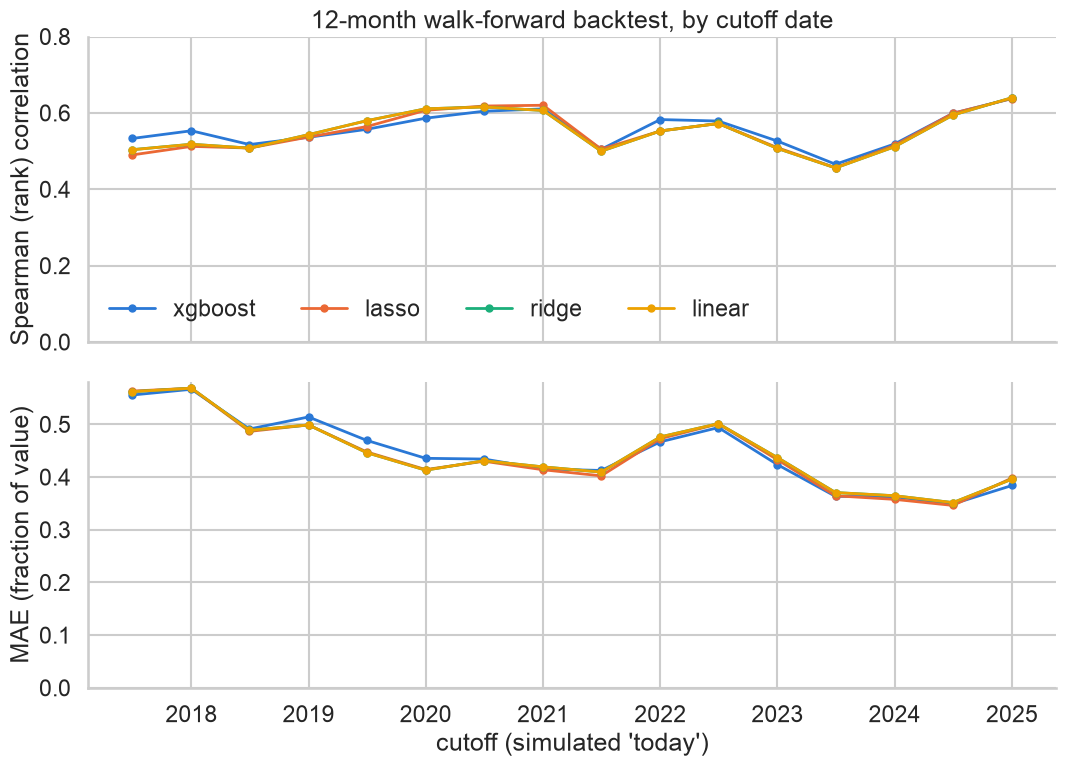

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
for name in MODEL_ORDER:
    rows = metrics_12m[metrics_12m["model"] == name].sort_values("cutoff")
    axes[0].plot(rows["cutoff"], rows["spearman"], color=MODEL_COLORS[name], linewidth=2, marker="o", markersize=5, label=name)
    axes[1].plot(rows["cutoff"], rows["mae"], color=MODEL_COLORS[name], linewidth=2, marker="o", markersize=5, label=name)

axes[0].set_ylabel("Spearman (rank) correlation")
axes[0].set_ylim(0, 0.8)
axes[0].axhline(0, color="#444444", linewidth=0.8)
axes[0].set_title("12-month walk-forward backtest, by cutoff date")
axes[0].legend(frameon=False, ncol=4, loc="lower left")

axes[1].set_ylabel("MAE (fraction of value)")
axes[1].set_ylim(0, axes[1].get_ylim()[1])
axes[1].set_xlabel("cutoff (simulated 'today')")

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

Two things stand out. First, the ranking quality is fairly flat over time, in a band from about 0.45 to 0.65: no sign that the model only worked in one market regime. Second, MAE drifts down at the most recent cutoffs; that's partly more training data and partly a quieter market in the eval window (compare `mean_actual_all` in the metrics table), so it shouldn't be read as the model getting sharper.

## Does it hold for shorter horizons?

The same exercise for 3, 6, and 9 months, XGBoost only. Shorter horizons have fewer usable cutoffs because the panel matches short-horizon targets within a tighter tolerance window, so fewer snapshots ever get a 3-month outcome.

In [5]:
horizon_rows = []
for months in HORIZONS_MONTHS:
    cutoffs = default_backtest_cutoffs(panel, months=months)
    m, _ = walk_forward_backtest(panel, months=months, cutoffs=cutoffs, model_names=("xgboost",))
    m["months"] = months
    horizon_rows.append(m)
horizon_metrics = pd.concat(horizon_rows, ignore_index=True)

horizon_summary = horizon_metrics.groupby("months").agg(
    n_cutoffs=("cutoff", "size"),
    first_cutoff=("cutoff", "min"),
    last_cutoff=("cutoff", "max"),
    spearman_mean=("spearman", "mean"),
    spearman_min=("spearman", "min"),
    spearman_max=("spearman", "max"),
    mae_mean=("mae", "mean"),
    direction_accuracy=("direction_accuracy", "mean"),
)
horizon_summary.round({c: 3 for c in horizon_summary.columns if c.startswith(('spearman', 'mae', 'direction'))})

,n_cutoffs,first_cutoff,last_cutoff,spearman_mean,spearman_min,spearman_max,mae_mean,direction_accuracy
months,,,,,,,,
3,11,2021-01-01,2026-01-01,0.582,0.488,0.706,0.214,0.782
6,19,2016-09-01,2025-09-01,0.494,0.375,0.633,0.275,0.729
9,18,2016-11-01,2025-05-01,0.524,0.416,0.614,0.365,0.721
12,16,2017-07-01,2025-01-01,0.557,0.466,0.638,0.446,0.708


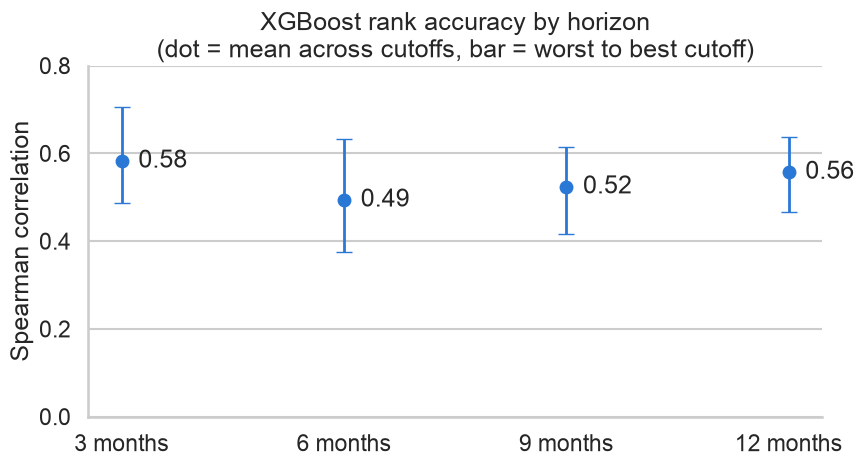

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(horizon_summary))
ax.errorbar(
    x,
    horizon_summary["spearman_mean"],
    yerr=[
        horizon_summary["spearman_mean"] - horizon_summary["spearman_min"],
        horizon_summary["spearman_max"] - horizon_summary["spearman_mean"],
    ],
    fmt="o",
    color=MODEL_COLORS["xgboost"],
    markersize=9,
    capsize=6,
    linewidth=2,
)
for xi, v in zip(x, horizon_summary["spearman_mean"]):
    ax.annotate(f"{v:.2f}", (xi, v), xytext=(12, 0), textcoords="offset points", va="center")
ax.set_xticks(x)
ax.set_xticklabels([f"{m} months" for m in horizon_summary.index])
ax.set_ylim(0, 0.8)
ax.set_ylabel("Spearman correlation")
ax.set_title("XGBoost rank accuracy by horizon\n(dot = mean across cutoffs, bar = worst to best cutoff)")
sns.despine(ax=ax)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

Rank accuracy is about the same at every horizon. The error in *size* grows with the horizon, as it should: more can happen in twelve months than in three.

## Is the top of the list actually worth acting on?

A scout doesn't care about the correlation across all 900 players; they care whether the handful the model flags most strongly really do rise. This compares the average realised change of the model's top 10% at each cutoff against the average across everyone.

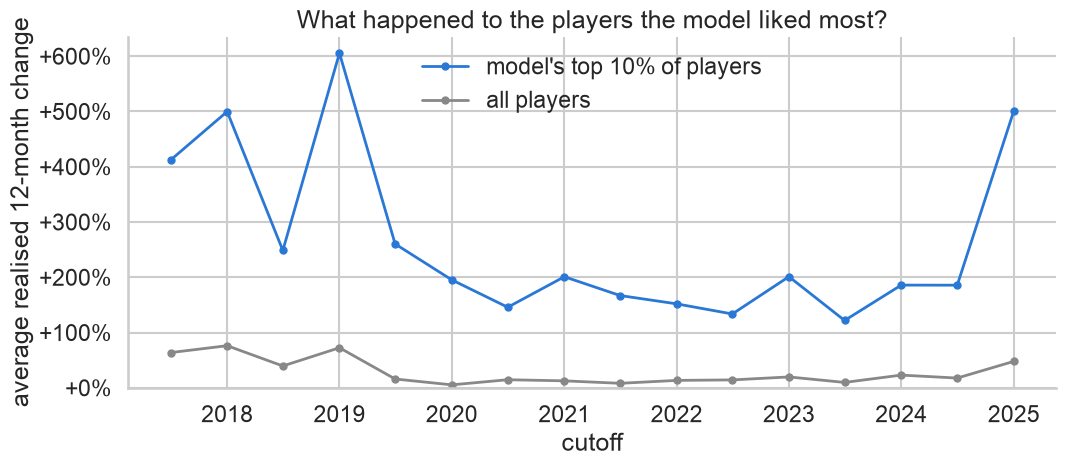

Top-decile players rose 10.4x more than the average player (median across cutoffs; worst cutoff 6.3x).


In [7]:
xgb_12m = metrics_12m[metrics_12m["model"] == "xgboost"].sort_values("cutoff")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(xgb_12m["cutoff"], xgb_12m["mean_actual_top_decile"] * 100, color=MODEL_COLORS["xgboost"], linewidth=2, marker="o", markersize=5, label="model's top 10% of players")
ax.plot(xgb_12m["cutoff"], xgb_12m["mean_actual_all"] * 100, color="#888888", linewidth=2, marker="o", markersize=5, label="all players")
ax.set_ylabel("average realised 12-month change")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:+.0f}%")
ax.set_ylim(0, ax.get_ylim()[1])
ax.set_xlabel("cutoff")
ax.set_title("What happened to the players the model liked most?")
ax.legend(frameon=False, loc="upper center")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

lift = (xgb_12m["mean_actual_top_decile"] / xgb_12m["mean_actual_all"])
print(f"Top-decile players rose {lift.median():.1f}x more than the average player (median across cutoffs; worst cutoff {lift.min():.1f}x).")

The players the model ranks in its top tenth grew several times more, on average, than the typical player, and that held at every single cutoff. This is the practical result: as a screening tool for "who is likely to rise", the model has been reliably useful. As a point forecast of *how much*, it hasn't.

## Can the sizing be fixed?

The first version of this notebook found the model called the *direction* well but undersized big moves, and blamed two design choices: training on a percentage-change target clipped at +500%, and a squared-error loss that a few breakouts dominate. This section tests the candidate fixes head to head, with the same walk-forward harness, for XGBoost with squared error and with a Huber loss:

- **raw % target, clip at 5x** (the original setup)
- **raw % target, clip at 20x** and **no clip** (let the model see the breakouts)
- **log-ratio target** `log(future / current)`, with and without the clip (symmetric in up/down moves, and it compresses breakouts so they stop dominating the loss)

In [8]:
configs = {
    "pct, clip 5x (original)": dict(target_transform="pct", clip=TARGET_CLIP),
    "pct, clip 20x": dict(target_transform="pct", clip=(-0.95, 20.0)),
    "pct, no clip": dict(target_transform="pct", clip=None),
    "log-ratio, clip 5x (default)": dict(target_transform="log_ratio", clip=TARGET_CLIP),
    "log-ratio, no clip": dict(target_transform="log_ratio", clip=None),
}
rows = []
for label, cfg in configs.items():
    m, _ = walk_forward_backtest(panel, months=12, cutoffs=cutoffs_12m, model_names=("xgboost", "xgboost_huber"), **cfg)
    per_model = m.groupby("model").agg(
        mae=("mae", "mean"),
        spearman=("spearman", "mean"),
        spearman_worst=("spearman", "min"),
        calibration_slope=("calibration_slope", "mean"),
        top_decile_predicted=("mean_predicted_top_decile", "mean"),
        top_decile_actual=("mean_actual_top_decile", "mean"),
    )
    per_model.insert(0, "config", label)
    rows.append(per_model.reset_index())
sizing = pd.concat(rows, ignore_index=True).set_index(["config", "model"])
sizing.round(3)

mae  spearman  spearman_worst  \
config                       model                                            
pct, clip 5x (original)      xgboost        0.515     0.533           0.444   
                             xgboost_huber  0.474     0.545           0.455   
pct, clip 20x                xgboost        0.607     0.517           0.426   
                             xgboost_huber  0.486     0.546           0.460   
pct, no clip                 xgboost        0.665     0.510           0.418   
                             xgboost_huber  0.486     0.545           0.458   
log-ratio, clip 5x (default) xgboost        0.446     0.557           0.466   
                             xgboost_huber  0.444     0.557           0.468   
log-ratio, no clip           xgboost        0.467     0.556           0.468   
                             xgboost_huber  0.458     0.557           0.466   

                                            calibration_slope  \
config                       model                              
pct, clip 5x (original)      xgboost                    0.720   
                             xgboost_huber              0.814   
pct, clip 20x                xgboost                    0.353   
                             xgboost_huber              0.608   
pct, no clip                 xgboost                    0.212   
                             xgboost_huber              0.610   
log-ratio, clip 5x (default) xgboost                    0.967   
                             xgboost_huber              0.963   
log-ratio, no clip           xgboost                    0.607   
                             xgboost_huber              0.661   

                                            top_decile_predicted  \
config                       model                                 
pct, clip 5x (original)      xgboost                       1.659   
                             xgboost_huber                 1.333   
pct, clip 20x                xgboost                       2.636   
                             xgboost_huber                 1.500   
pct, no clip                 xgboost                       3.153   
                             xgboost_huber                 1.501   
log-ratio, clip 5x (default) xgboost                       1.106   
                             xgboost_huber                 1.087   
log-ratio, no clip           xgboost                       1.477   
                             xgboost_huber                 1.336   

                                            top_decile_actual  
config                       model                             
pct, clip 5x (original)      xgboost                    2.636  
                             xgboost_huber              2.603  
pct, clip 20x                xgboost                    2.574  
                             xgboost_huber              2.585  
pct, no clip                 xgboost                    2.456  
                             xgboost_huber              2.594  
log-ratio, clip 5x (default) xgboost                    2.635  
                             xgboost_huber              2.613  
log-ratio, no clip           xgboost                    2.620  
                             xgboost_huber              2.576

The log-ratio target wins on every column at once: lowest error, highest and most stable rank correlation, and a calibration slope of about 0.97, i.e. the sizes of predicted moves are right on average. It also makes the loss choice irrelevant (Huber and squared error land in the same place). It is now the default for every model in `src/modeling.py`, which is also why the linear models in the first table of this notebook do so much better than they did in notebook 02.

Letting the raw-percentage model see the breakouts is actively harmful: with the clip loosened or removed, the calibration slope collapses to 0.2-0.35, meaning the model starts predicting huge moves for many players who then don't deliver them. Huber loss softens that but doesn't fix it.

What *can't* be fixed is the last column. The average realised change of the model's top-decile picks is around +260%, against a prediction of around +110%, and that gap is driven by a few teenagers going from a few hundred thousand euros to tens of millions. Those are outliers no feature in this dataset foreshadows; a model that tried to predict them would (as the loosened-clip rows show) simply over-predict everyone else.

## Saying how sure we are: prediction intervals

Given a point forecast is only reliable to within a wide band, an honest output is the band itself. Quantile regression gives a 10th and 90th percentile prediction per player; if those are calibrated, the real outcome should land inside the band about 80% of the time. This checks that walk-forward, too.

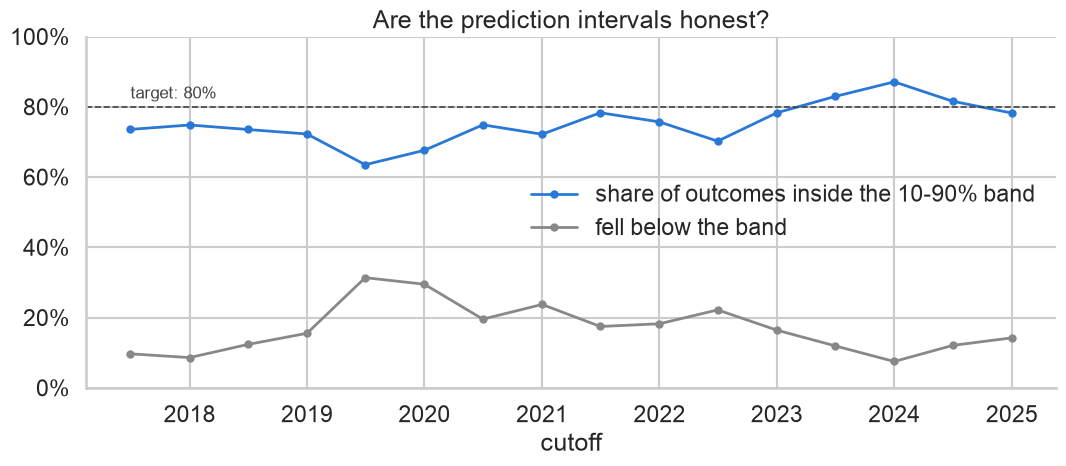

Mean coverage across cutoffs: 75% (target 80%); median band width 95% of current value.


In [9]:
interval_12m = walk_forward_interval_backtest(panel, months=12, cutoffs=cutoffs_12m, quantiles=(0.1, 0.9))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(interval_12m["cutoff"], interval_12m["coverage"] * 100, color=MODEL_COLORS["xgboost"], linewidth=2, marker="o", markersize=5, label="share of outcomes inside the 10-90% band")
ax.plot(interval_12m["cutoff"], interval_12m["below_low"] * 100, color="#888888", linewidth=2, marker="o", markersize=5, label="fell below the band")
ax.axhline(80, color="#444444", linestyle="--", linewidth=1.2)
ax.annotate("target: 80%", (interval_12m["cutoff"].iloc[0], 80), xytext=(0, 6), textcoords="offset points", fontsize=12, color="#444444")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0f}%")
ax.set_xlabel("cutoff")
ax.set_title("Are the prediction intervals honest?")
ax.legend(frameon=False, loc="center right")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print(f"Mean coverage across cutoffs: {interval_12m['coverage'].mean():.0%} (target 80%); median band width {interval_12m['median_width'].median():.0%} of current value.")

Coverage sits a little under the 80% target on average, and the miss is concentrated in two cutoffs: mid-2019 and early 2020. In both, far more players fell *below* the band than the model expected. Those are the evaluation windows that include the pandemic, when Transfermarkt marked down valuations across the board in spring 2020. Nothing in a player's own history could have predicted a market-wide cut, so the intervals were wrong in exactly the way one would expect. Outside those windows the band is close to honest.

The median band is roughly as wide as the player's current value, which is the real answer to "how precisely can this be predicted": to within about plus or minus half the current value, most of the time.

## Case study: June 2025

The single rollback the first version of this notebook used, kept as a worked example of what one cutoff looks like underneath the summary numbers. Note this cutoff is later than the last default one: some players' 12-month outcomes hadn't been re-valued by the end of the data, so the eval set is a little smaller and possibly biased toward players who *did* get re-valued.

Trained on 23,761 snapshots, evaluated on 562 players.
MAE 0.41 | Pearson 0.56 | Spearman 0.61 | direction right 74%


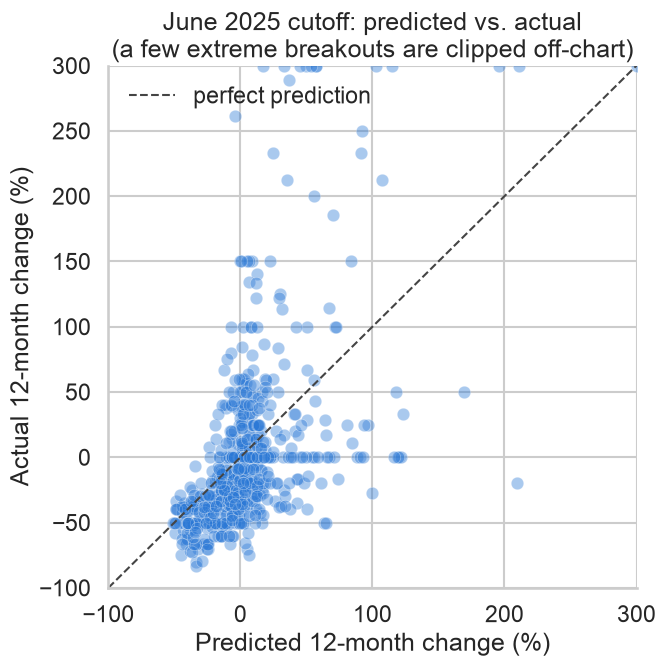

In [10]:
case_metrics, case_preds = walk_forward_backtest(
    panel, months=12, cutoffs=[pd.Timestamp("2025-06-01")], model_names=("xgboost",)
)
case = case_preds.copy()
row = case_metrics.iloc[0]
print(f"Trained on {row['n_train']:,} snapshots, evaluated on {row['n_eval']} players.")
print(f"MAE {row['mae']:.2f} | Pearson {row['pearson']:.2f} | Spearman {row['spearman']:.2f} | direction right {row['direction_accuracy']:.0%}")

plot_data = case.copy()
plot_data["predicted"] = plot_data["predicted_pct_change"].clip(-1, 3) * 100
plot_data["actual"] = plot_data["actual_pct_change"].clip(-1, 3) * 100

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(plot_data["predicted"], plot_data["actual"], alpha=0.4, color=MODEL_COLORS["xgboost"], edgecolor="white", linewidth=0.5)
lims = [-100, 300]
ax.plot(lims, lims, color="#444444", linestyle="--", linewidth=1.5, label="perfect prediction")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Predicted 12-month change (%)")
ax.set_ylabel("Actual 12-month change (%)")
ax.set_title("June 2025 cutoff: predicted vs. actual\n(a few extreme breakouts are clipped off-chart)")
ax.legend(loc="upper left", frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [11]:
top10 = case.sort_values("predicted_pct_change", ascending=False).head(10).copy()
top10["Predicted change"] = (top10["predicted_pct_change"] * 100).round(0).astype(int).map("{:+d}%".format)
top10["Actual change"] = (top10["actual_pct_change"] * 100).round(0).astype(int).map("{:+d}%".format)
top10 = top10.rename(columns={"name": "Player", "sub_position": "Position"})
top10[["Player", "Position", "Predicted change", "Actual change"]].reset_index(drop=True)

,Player,Position,Predicted change,Actual change
0,Mikey Moore,Left Winger,+308%,+1700%
1,Josh King,Attacking Midfield,+211%,+2400%
2,Eric da Silva Moreira,Right-Back,+209%,-20%
3,Harrison Armstrong,Central Midfield,+196%,+2300%
4,Louie Marsh,Second Striker,+169%,+50%
5,James Carragher,Centre-Back,+123%,+33%
6,Nathan Fraser,Centre-Forward,+122%,+0%
7,Tammer Bany,Centre-Forward,+120%,+0%
8,Ryan Trevitt,Central Midfield,+119%,+0%
9,Tyler Bindon,Centre-Back,+118%,+50%


The same pattern the summary shows, at the level of named players. Six of the top ten rose, and three of those rose by an order of magnitude more than predicted; three didn't move at all and one fell. Two things to notice. The names are all teenagers on tiny valuations, because the biggest *percentage* gains are only possible from a low base, so the "% risers" list is really a list of academy prospects. And the model undersizes genuine breakouts, which is consistent with training on a clipped target and a squared-error loss.

## Caveats

- The evaluation set at each cutoff is players who *did* get re-valued near the target date. Players who went un-valued for a long stretch (often those who left the league) aren't represented, so the numbers describe "players still being tracked" rather than every player.
- Cutoffs six months apart share most of their training data, so the 16 cutoffs are not 16 independent trials. They are, however, 16 genuinely different evaluation windows, which is what matters for "did it work in different years".
- Everything the model can't see (injuries, contract situations, transfer speculation, managerial change) is exactly what drives the biggest misses, and none of it is in the features.